# Smart City Sensor Data – Exploratory Data Analysis (EDA)

**Dataset Source:** Grant No. BR24992852 – *“Intelligent models and methods of Smart City digital ecosystem for sustainable development and the citizens’ quality of life improvement”*.

This notebook performs Exploratory Data Analysis (EDA) on IoT sensor data collected every 5 seconds over a week.  
Sensors include:

- Temperature
- Humidity
- Light
- pH
- Electrical Conductivity (EC)

We will:

1. Load and combine the daily CSV files.
2. Explore basic structure and statistics.
3. Plot trends and correlations between **temperature**, **humidity**, and **light**.
4. Identify patterns such as **day–night light cycles** and **relationships between temperature and humidity**.
5. Compute basic statistics (mean, min, max, variance) for each sensor.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display plots inline
%matplotlib inline

plt.style.use("default")
sns.set_theme()



## 1. Load and Combine Daily CSV Files

This cell looks for CSV files in a `data/` folder first.  
If no files are found there, it falls back to the current folder.


In [2]:
# Look for CSVs in 'data/' folder first
data_dir = Path("data")
csv_files = sorted(data_dir.glob("*.csv"))

# If there are no files in 'data/', fall back to current directory
if not csv_files:
    csv_files = sorted(Path(".").glob("*.csv"))

print("CSV files found:")
for f in csv_files:
    print(" -", f)

if not csv_files:
    raise FileNotFoundError("No CSV files found. Please place your daily sensor CSVs in a 'data' folder or alongside this notebook.")


CSV files found:
 - data\sensor_data_2025-03-01.csv
 - data\sensor_data_2025-03-02.csv
 - data\sensor_data_2025-03-03.csv
 - data\sensor_data_2025-03-04.csv
 - data\sensor_data_2025-03-05.csv
 - data\sensor_data_2025-03-06.csv
 - data\sensor_data_2025-03-07.csv


In [3]:
# Read and combine all CSV files into a single DataFrame
df_list = [
    pd.read_csv(f, parse_dates=["timestamp"])
    for f in csv_files
]

df = pd.concat(df_list, ignore_index=True)
df.head()


,timestamp,temperature,humidity,light,pH,electrical_conductivity
0,2025-03-01 00:00:00,24.69,52.66,118.65,6.68,0.996
1,2025-03-01 00:00:05,21.89,50.18,801.71,7.29,1.044
2,2025-03-01 00:00:10,23.88,48.01,682.39,7.66,1.354
3,2025-03-01 00:00:15,20.42,56.73,146.05,7.77,0.519
4,2025-03-01 00:00:20,20.79,41.54,106.87,7.77,1.900


## 2. Basic Dataset Overview

We check the structure, basic statistics, and missing values.


In [4]:
# Structure of the combined dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120960 entries, 0 to 120959
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   timestamp                120960 non-null  datetime64[ns]
 1   temperature              120960 non-null  float64       
 2   humidity                 120960 non-null  float64       
 3   light                    120960 non-null  float64       
 4   pH                       120960 non-null  float64       
 5   electrical_conductivity  120960 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 5.5 MB


In [5]:
# Summary statistics for numeric columns
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,120960,2025-03-04 11:59:57.499999744,2025-03-01 00:00:00,2025-03-02 17:59:58.750000128,2025-03-04 11:59:57.500000,2025-03-06 05:59:56.249999872,2025-03-07 23:59:55,NaN
temperature,120960.0,22.500301,20.0,21.25,22.5,23.75,25.0,1.442144
humidity,120960.0,50.026163,40.0,45.05,50.06,55.01,60.0,5.766784
light,120960.0,549.10379,100.0,323.67,548.91,773.69,999.99,259.726259
pH,120960.0,7.000135,6.0,6.5,7.0,7.5,8.0,0.576866
electrical_conductivity,120960.0,1.249303,0.5,0.875,1.249,1.625,2.0,0.433405


In [6]:
# Missing values per column
df.isna().sum()

timestamp                  0
temperature                0
humidity                   0
light                      0
pH                         0
electrical_conductivity    0
dtype: int64

## 3. Time-Based Features

We extract **date** and **hour** from the timestamp to analyze daily and hourly patterns.


In [7]:
# Create helper time columns
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour

df[["timestamp", "date", "hour"]].head()


,timestamp,date,hour
0,2025-03-01 00:00:00,2025-03-01,0
1,2025-03-01 00:00:05,2025-03-01,0
2,2025-03-01 00:00:10,2025-03-01,0
3,2025-03-01 00:00:15,2025-03-01,0
4,2025-03-01 00:00:20,2025-03-01,0


## 4. Trend Plots for an Example Day

We pick the first day in the dataset and plot **temperature**, **humidity**, and **light** over time to see how they evolve within a day.


In [8]:
# Select the first day in the dataset
first_day = df["date"].min()
one_day = df[df["date"] == first_day].copy()

print("Example day:", first_day)
one_day.head()


Example day: 2025-03-01


,timestamp,temperature,humidity,light,pH,electrical_conductivity,date,hour
0,2025-03-01 00:00:00,24.69,52.66,118.65,6.68,0.996,2025-03-01,0
1,2025-03-01 00:00:05,21.89,50.18,801.71,7.29,1.044,2025-03-01,0
2,2025-03-01 00:00:10,23.88,48.01,682.39,7.66,1.354,2025-03-01,0
3,2025-03-01 00:00:15,20.42,56.73,146.05,7.77,0.519,2025-03-01,0
4,2025-03-01 00:00:20,20.79,41.54,106.87,7.77,1.900,2025-03-01,0


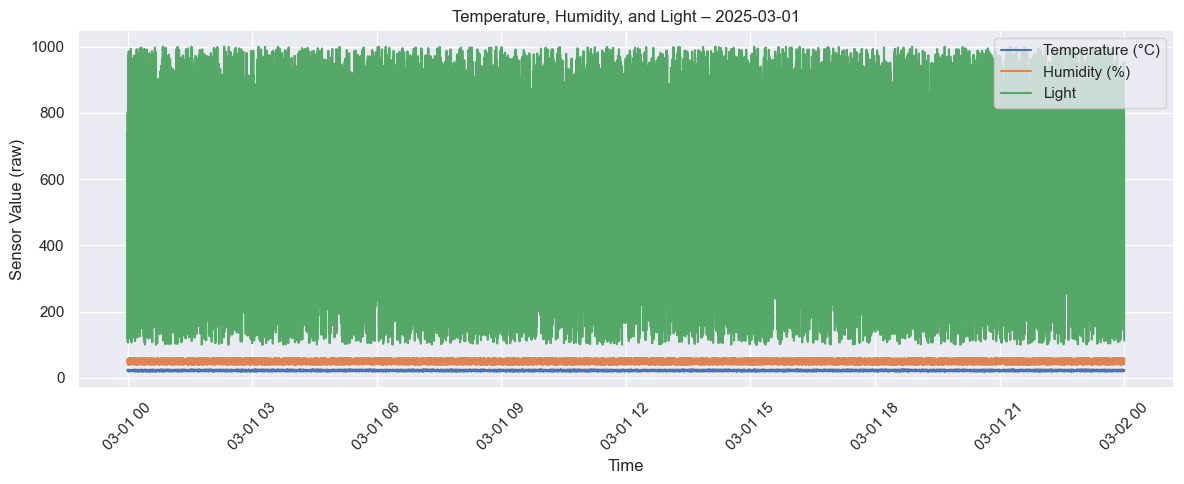

In [9]:
# Plot temperature, humidity, and light for the example day
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(one_day["timestamp"], one_day["temperature"], label="Temperature (°C)")
ax.plot(one_day["timestamp"], one_day["humidity"], label="Humidity (%)")
ax.plot(one_day["timestamp"], one_day["light"], label="Light")

ax.set_title(f"Temperature, Humidity, and Light – {first_day}")
ax.set_xlabel("Time")
ax.set_ylabel("Sensor Value (raw)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Hourly Averages – Day–Night Patterns

We group the data by **hour of the day (0–23)** and compute the average temperature, humidity, and light.  
This reveals **typical daily patterns**, such as:

- Light being low at night and high during the day.
- Temperature and humidity trends across the day.


In [10]:
# Hourly mean values across the entire week
hourly_mean = df.groupby("hour")[["temperature", "humidity", "light"]].mean()
hourly_mean.head()


,temperature,humidity,light
hour,,,
0,22.486442,50.052891,549.796238
1,22.472857,50.074171,548.577121
2,22.510361,49.865665,552.316163
3,22.505956,50.099629,550.011635
4,22.485714,49.958905,553.290444


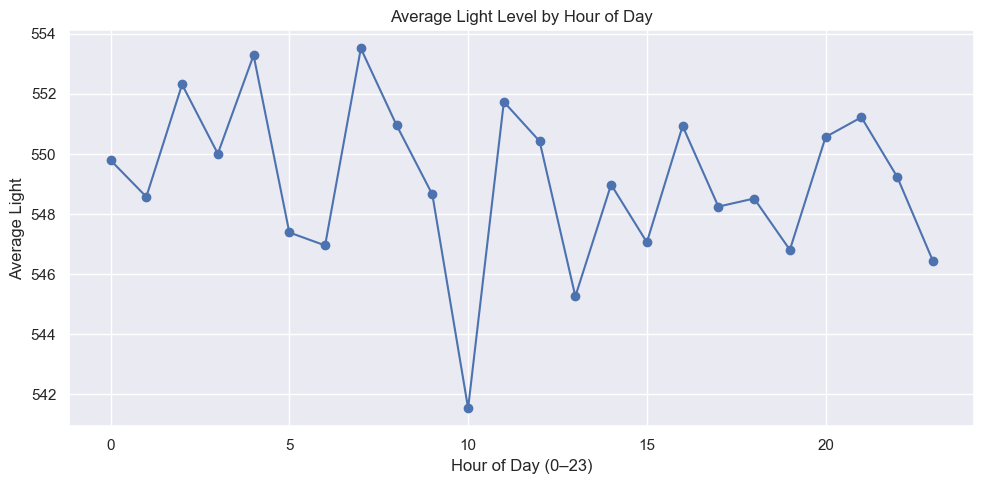

In [11]:
# Plot hourly average light (day–night pattern)
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(hourly_mean.index, hourly_mean["light"], marker="o")
ax.set_title("Average Light Level by Hour of Day")
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("Average Light")
ax.grid(True)

plt.tight_layout()
plt.show()


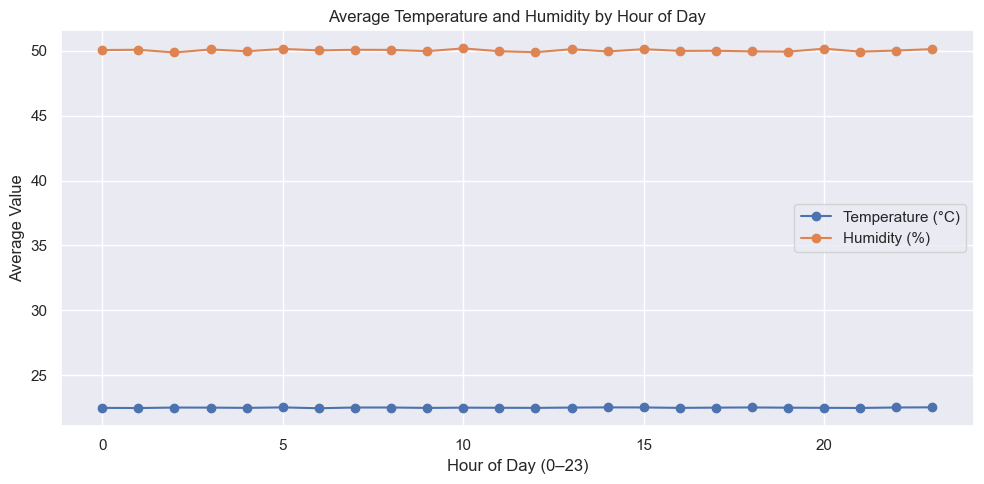

In [12]:
# Plot hourly average temperature and humidity
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(hourly_mean.index, hourly_mean["temperature"], marker="o", label="Temperature (°C)")
ax.plot(hourly_mean.index, hourly_mean["humidity"], marker="o", label="Humidity (%)")

ax.set_title("Average Temperature and Humidity by Hour of Day")
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("Average Value")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


## 6. Correlations Between Temperature, Humidity, and Light

We examine how the three main environmental variables relate to each other:

- Temperature vs. Humidity (often an inverse relationship).
- Temperature vs. Light.
- Humidity vs. Light.


In [13]:
# Select the relevant columns
subset = df[["temperature", "humidity", "light"]]

# Correlation matrix
corr = subset.corr()
corr

,temperature,humidity,light
temperature,1.000000,0.003655,-0.000423
humidity,0.003655,1.000000,-0.001196
light,-0.000423,-0.001196,1.000000


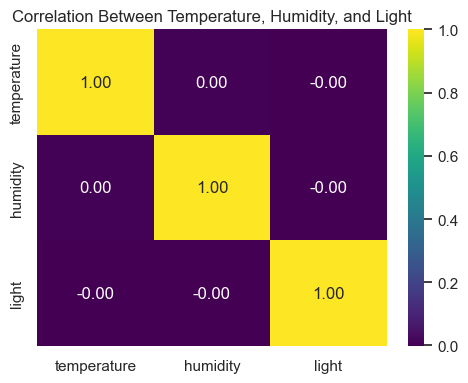

In [14]:
# Correlation heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis")
plt.title("Correlation Between Temperature, Humidity, and Light")
plt.tight_layout()
plt.show()


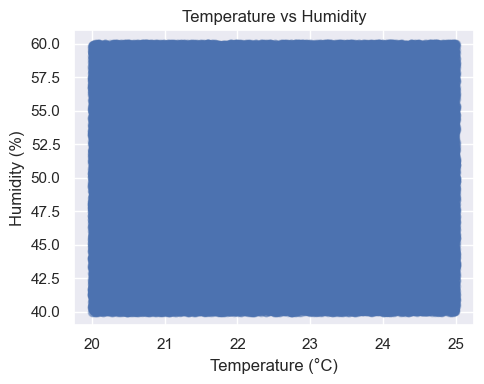

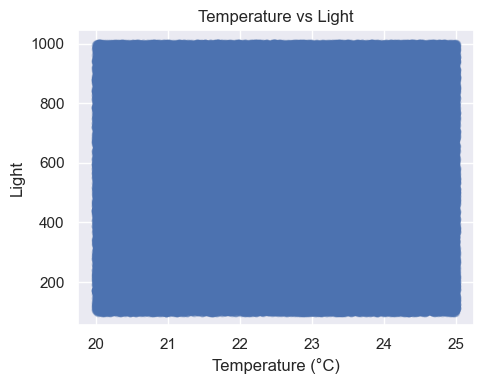

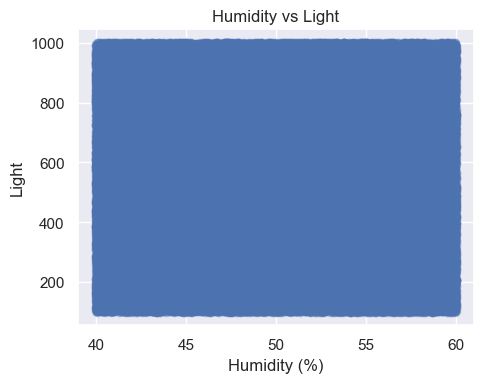

In [15]:
# Scatter plots to visualize relationships
plt.figure(figsize=(5, 4))
plt.scatter(df["temperature"], df["humidity"], alpha=0.3)
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.scatter(df["temperature"], df["light"], alpha=0.3)
plt.title("Temperature vs Light")
plt.xlabel("Temperature (°C)")
plt.ylabel("Light")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.scatter(df["humidity"], df["light"], alpha=0.3)
plt.title("Humidity vs Light")
plt.xlabel("Humidity (%)")
plt.ylabel("Light")
plt.tight_layout()
plt.show()


## 7. Basic Statistics per Sensor

We compute **mean**, **minimum**, **maximum**, and **variance** for each sensor:

- Temperature  
- Humidity  
- Light  
- pH  
- Electrical Conductivity (EC)  


In [16]:
sensors = ["temperature", "humidity", "light", "pH", "electrical_conductivity"]

stats = pd.DataFrame({
    "mean": df[sensors].mean(),
    "min": df[sensors].min(),
    "max": df[sensors].max(),
    "variance": df[sensors].var()
})

stats

,mean,min,max,variance
temperature,22.500301,20.0,25.00,2.079780
humidity,50.026163,40.0,60.00,33.255800
light,549.103790,100.0,999.99,67457.729719
pH,7.000135,6.0,8.00,0.332774
electrical_conductivity,1.249303,0.5,2.00,0.187840


## 8. Saving Plots for Use in README

The next cell recreates key plots and saves them as PNG files in a `plots/` folder. 


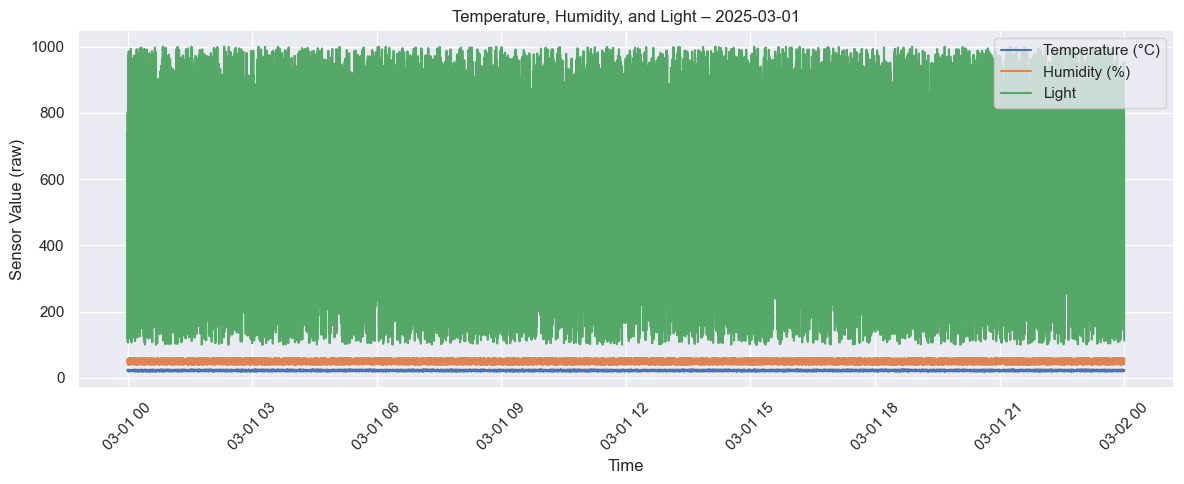

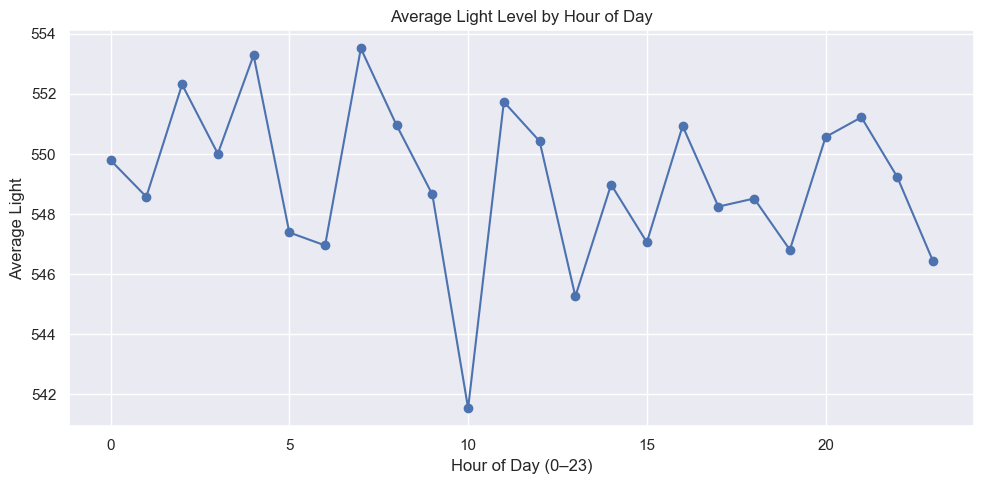

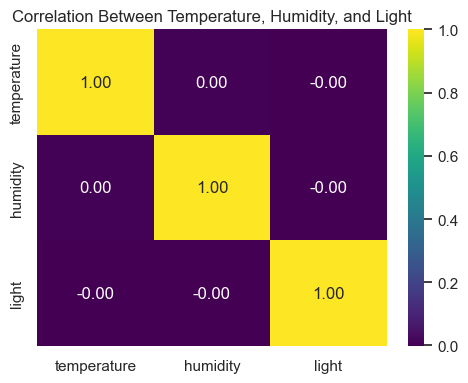

In [17]:
plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)

# 1) Example day line plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(one_day["timestamp"], one_day["temperature"], label="Temperature (°C)")
ax.plot(one_day["timestamp"], one_day["humidity"], label="Humidity (%)")
ax.plot(one_day["timestamp"], one_day["light"], label="Light")
ax.set_title(f"Temperature, Humidity, and Light – {first_day}")
ax.set_xlabel("Time")
ax.set_ylabel("Sensor Value (raw)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(plots_dir / "daily_temp_hum_light.png", dpi=150)
plt.show()

# 2) Hourly light pattern
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly_mean.index, hourly_mean["light"], marker="o")
ax.set_title("Average Light Level by Hour of Day")
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("Average Light")
ax.grid(True)
plt.tight_layout()
fig.savefig(plots_dir / "hourly_light_pattern.png", dpi=150)
plt.show()

# 3) Correlation heatmap
fig = plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis")
plt.title("Correlation Between Temperature, Humidity, and Light")
plt.tight_layout()
fig.savefig(plots_dir / "correlation_temp_hum_light.png", dpi=150)
plt.show()
